In [98]:
import numpy as np
import matplotlib.pyplot as plt
from numpyro.distributions.transforms import StickBreakingTransform
import scipy.stats as sps
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

from sbayes.util import normalize


In [3]:
# Generate data from a 3 state Dirichlet distribution
x = np.random.dirichlet([1, 1, 1], size=200)

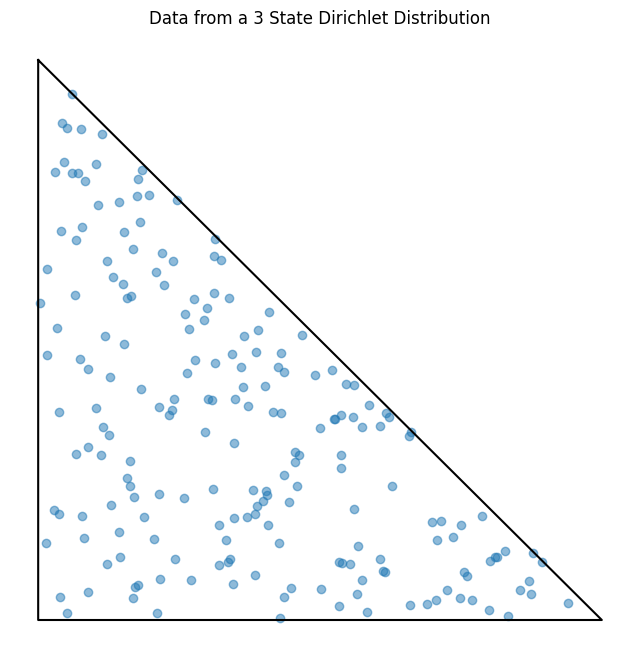

In [4]:
# Plot the data in a 2D representation of the 3D simplex
plt.figure(figsize=(8, 8))
plt.scatter(x[:, 0], x[:, 1], alpha=0.5)
plt.plot([0, 1, 0, 0], [1, 0, 0, 1], color='black')  # simplex edges
plt.axis('off')
plt.title('Data from a 3 State Dirichlet Distribution')
plt.show()

In [5]:
# Define stretch-and-clip transformation
def stretch_and_clip(x, stretch_factor):
    """
    Stretch the last dimension of the input and clip the values to [0, 1].
    """
    y = np.copy(x)
    y[:, -1] *= stretch_factor  # stretch the last dimension
    y[:, :-1] -= normalize(y[:, :-1]) * (y[:, -1:] - x[:, -1:])
    return np.clip(y, 0, 1)

y = stretch_and_clip(x, 1.1)

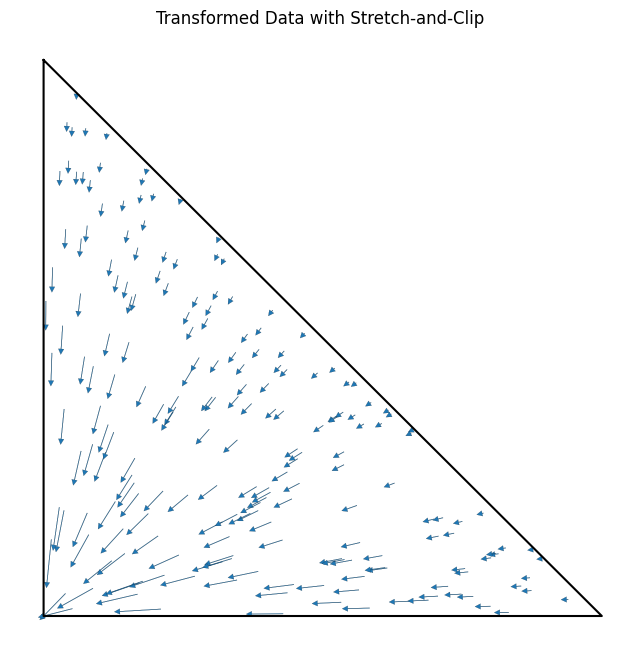

In [6]:
# Plot the transformed data
plt.figure(figsize=(8, 8))
# Arrows from original to transformed points
for i in range(len(x)):
    plt.arrow(x[i, 0], x[i, 1], y[i, 0] - x[i, 0], y[i, 1] - x[i, 1],
              head_width=0.01, head_length=0.01, lw=0.1, ec='k')

plt.plot([0, 1, 0, 0], [1, 0, 0, 1], color='black')  # simplex edges
plt.axis('off')
plt.title('Transformed Data with Stretch-and-Clip')
plt.show()

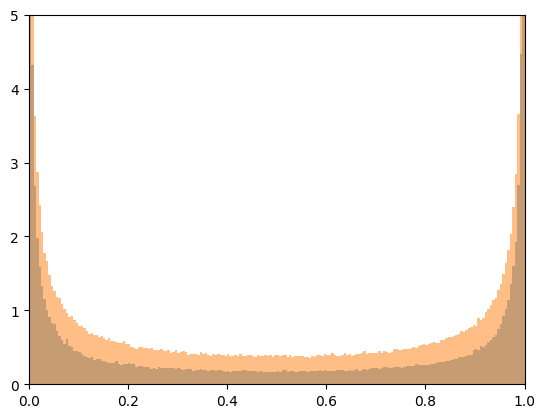

In [7]:
# Show the same with two states
x2 = np.random.dirichlet([0.1, 0.1], size=500000)
y2 = np.random.dirichlet([0.25, 0.25], size=500000)

# y2 = stretch_and_clip(x2, 1.05)

plt.hist(x2[:, 0], bins=200, alpha=0.5, label='Original', density=True)
plt.hist(y2[:, 0], bins=200, alpha=0.5, label='Transformed', density=True)
plt.xlim(0, 1)
plt.ylim(0, 5)
plt.show()

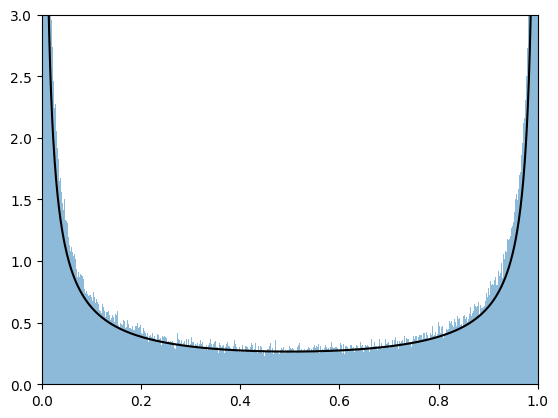

In [22]:
# Compare dirichlet with logistic normal
D = 2
S = 500_000

C = 0.16
# x_d = np.random.dirichlet(C*np.ones(D), size=S)
# x_d = stretch_and_clip(x_d, 1.1)

SCALE = 4
z = np.random.normal(loc=0, scale=SCALE, size=(S, D))
x_ln = normalize(np.exp(z), axis=-1)
# x_ln = stretch_and_clip(x_ln, 1.1)

# plt.hist(x_d[:, 0], bins=100, alpha=0.5, label='Original', density=True, log=False)
plt.hist(x_ln[:, 0], bins=1000, alpha=0.5, label='Transformed', density=True, log=False)

t = np.linspace(0, 1, 1000)
diri = sps.beta(C, (D-1)*C)
plt.plot(t, diri.pdf(t), label='Beta PDF', color='black')
# plt.plot(t, diri.cdf(t), label='Beta CDF', color='black')

plt.xlim(0.0, 1.0)
plt.ylim(0, 3)
plt.show()

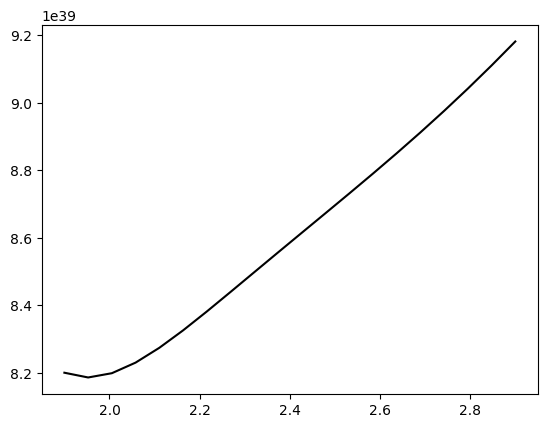

In [43]:
# Find best logistic-normal scale to match Dirichlet
D = 8
S = 1_000

# Define Dirichlet distribution
C = 0.05
diri = sps.dirichlet(C * np.ones(D))
x_diri = diri.rvs(size=S)
x_diri = normalize(x_diri + 1E-8, axis=-1)

def normalize(x, axis=-1):
    return (x / np.sum(x, axis=axis, keepdims=True))

# Find best scale for logistic-normal
SCALE_VALUES = np.linspace(1.9, 2.9, 20)
score = np.zeros(len(SCALE_VALUES))
z = np.random.normal(loc=0, scale=1, size=(S, D))
for i_s, s in enumerate(SCALE_VALUES):
    x_ln = normalize(np.exp(s*z), axis=-1)
    kde = sps.gaussian_kde(x_ln.T[:-1])
    q = kde.evaluate(x_diri.T[:-1])
    p = diri.pdf(x_diri.T[:-1])
    score[i_s] = np.mean(p / q * np.log(p / q))

plt.plot(SCALE_VALUES, score, color='black')
# a = 3**(1/D)
# plt.axvline(a, color='red', linestyle='--', label='a = 3^(1/D)')
# i_a = np.argmin(np.abs(SCALE_VALUES - a))
# plt.axhline(score[i_a], color='red', linestyle='--', label='Score at a')
plt.show()

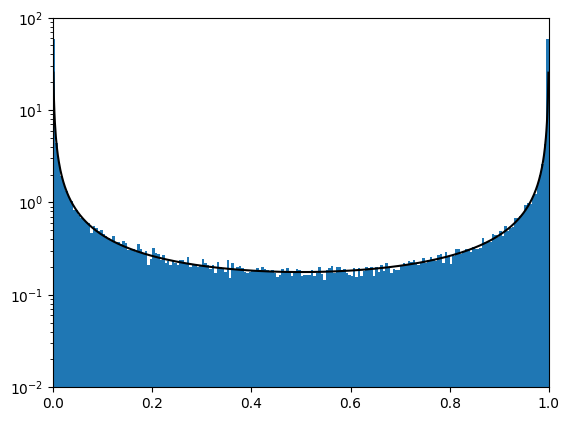

In [233]:
C = 0.1

def model_dirichlet():
    return numpyro.sample('dirichlet', dist.Dirichlet(jnp.array([C, C])))

def plot_samples_vs_analytical_pdf(samples, bins=100):
    # Plot the histogram of samples
    plt.hist(samples, bins=bins, density=True)

    # Plot the analytical PDF of the Dirichlet distribution (C, C)
    t = np.linspace(0, 1, 1000)
    plt.plot(t, sps.beta(C, C).pdf(t), label='Beta PDF', color='black')

    # Change y-axis to log scale
    plt.yscale('log')

    plt.xlim(0, 1)
    plt.ylim(0.01, 100)
    plt.show()

with numpyro.handlers.seed(rng_seed=jax.random.PRNGKey(14)):
    with numpyro.plate("samples", 100000, dim=-1):
        samples = model_dirichlet()[:, 0]

plot_samples_vs_analytical_pdf(samples, bins=200)

With MCMC:

sample: 100%|██████████| 21000/21000 [01:03<00:00, 332.25it/s, 4095 steps of size 7.35e-01. acc. prob=0.93]


{'dirichlet': Array([-215878.33], dtype=float32)}


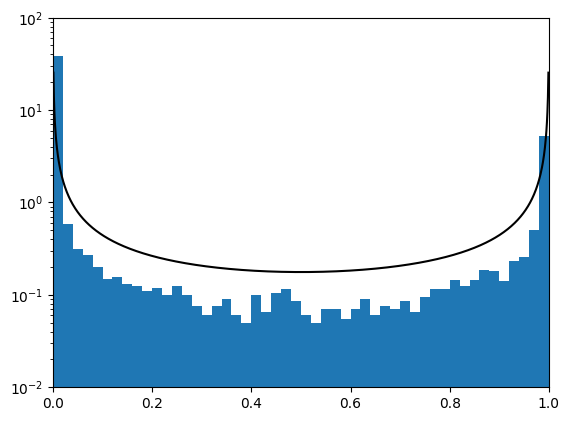

In [241]:
from numpyro.infer import MCMC, NUTS

def run_nuts(model, num_samples, thinning):
    kernel = NUTS(model, max_tree_depth=12, target_accept_prob=0.75, find_heuristic_step_size=True)
    mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples*thinning, thinning=thinning)
    mcmc.run(jax.random.PRNGKey(np.random.randint(2147483647)))
    samples = mcmc.get_samples()
    print(mcmc.last_state.z)
    return samples['dirichlet'][:, 0]

samples = run_nuts(model_dirichlet, 10000, 2)
plot_samples_vs_analytical_pdf(samples, bins=50)

With MCMC but on a transformed model, correcting for volume distortion effects:

sample: 100%|██████████| 101000/101000 [00:09<00:00, 10791.39it/s, 3 steps of size 7.63e-01. acc. prob=0.85]


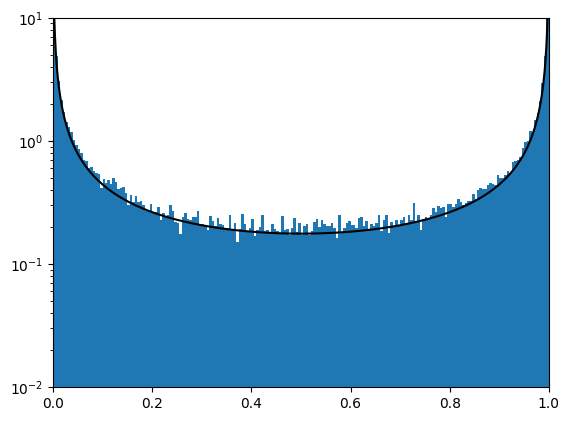

In [211]:
transform = StickBreakingTransform()

def model_dirichlet_latent_good():
    latent_dist = dist.Uniform(-50, 50)
    diri_dist = dist.Dirichlet(jnp.array([C, C]))
    with numpyro.plate("latent_dim", 1, dim=-1):
        latent = numpyro.sample('latent', latent_dist)
    dirichlet_samples = numpyro.deterministic('dirichlet', transform(latent))
    numpyro.factor(
        'dirichlet_logpdf',
        diri_dist.log_prob(dirichlet_samples)
        + transform.log_abs_det_jacobian(latent, dirichlet_samples)
    )
    return dirichlet_samples

samples = run_nuts(model_dirichlet_latent_good, 100000, 1)
plot_samples_vs_analytical_pdf(samples, bins=200)

(50000,)


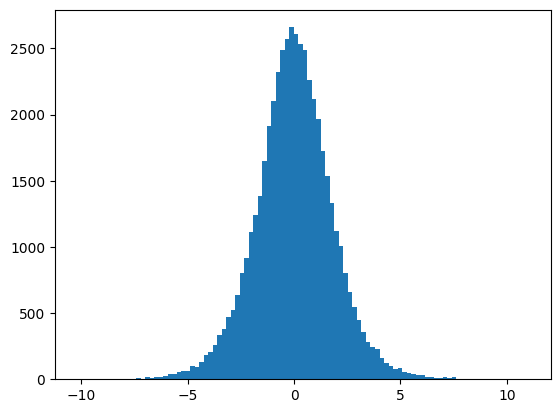

In [182]:
x = jax.random.beta(jax.random.PRNGKey(14), 1., 1., shape=(50000,))
x = transform.inv(jnp.array([x, 1-x]).T)[:, 0]
print(x.shape)
plt.hist(x, bins=100)
# plt.xlim(0, 1)
plt.show()

In [338]:

def dirichlet_from_latent(name: str, concentration, offset = None):
    n_states = concentration.shape[-1]
    n_states_latent = n_states - 1

    # Sample from uniform distribution in latent space that spans wide enough to cover the tails
    x_latent_distr = dist.Uniform(-50, 50).expand((n_states_latent,)).to_event()
    # x_latent_distr = dist.ImproperUniform(dist.constraints.real, (), ()).expand((n_states_latent,)).to_event()
    x_latent = numpyro.sample(f"{name}_raw", x_latent_distr)

    # Define a stick breaking transform to convert to real space
    trans = StickBreakingTransform()

    # If offset is provided, add it in latent space
    if offset is not None:
        offset_latent = trans.inv(offset)
        x_latent += offset_latent

    # Transform to probability simplex
    x = trans(x_latent)

    # Define the dirichlet distribution on probability simplex
    x_distr = dist.Dirichlet(concentration)
    prior_log_prob = x_distr.log_prob(x)

    # Compute the correction factor to get the correct probability density on the simplex
    prior_correction_factor = trans.log_abs_det_jacobian(x_latent, x) -  x_latent_distr.log_prob(x_latent)

    # Add the corrected log probability as a factor
    corrected_log_prob = prior_log_prob + prior_correction_factor
    numpyro.factor(f"{name}_log_prob", corrected_log_prob)
    numpyro.deterministic(f"{name}_latent_log_prob", x_latent_distr.log_prob(x_latent))

    # Add the sampled transformed value to the state
    numpyro.deterministic(name, x)

    return x

def run_nuts(model, num_samples, thinning):
    kernel = NUTS(model, max_tree_depth=12, target_accept_prob=0.75, find_heuristic_step_size=True)
    mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples*thinning, thinning=thinning)
    mcmc.run(jax.random.PRNGKey(np.random.randint(2147483647)))
    samples = mcmc.get_samples()
    mcmc.print_summary()
    return samples

sample: 100%|██████████| 21000/21000 [00:03<00:00, 5686.75it/s, 5 steps of size 4.34e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  x_raw[0]     -2.56     11.03     -1.08    -17.68     16.19   3147.02      1.00

Number of divergences: 0

log_likelihood
-3.8373914
potential_energy
448062.38


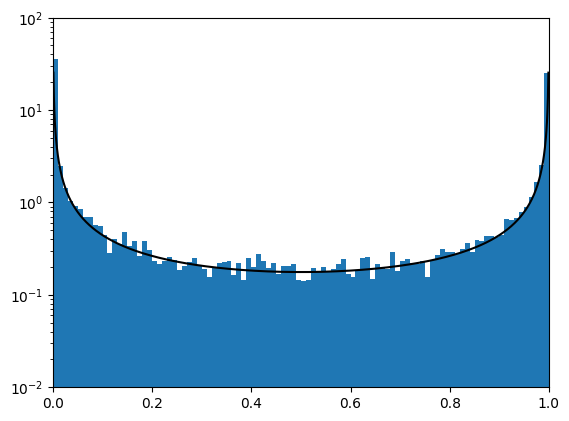

In [343]:
from numpyro.infer.util import log_likelihood, potential_energy, log_density


def model_dirichlet_latent_2():
    return dirichlet_from_latent('x', C * jnp.ones(2))

samples = run_nuts(model_dirichlet_latent_2, 20_000, 1)

print()
print('log_likelihood')
print(np.mean(log_likelihood(model_dirichlet_latent_2, samples)['x_log_prob'] + samples['x_latent_log_prob']))
print('potential_energy')
print(potential_energy(model_dirichlet_latent_2, (), {}, params=samples))

plot_samples_vs_analytical_pdf(samples['x'][:, 0], bins=100)